# Phase 4 — Visualisations

Cette phase a pour but d'illustrer les insights de la **phase trois sur l'analyse**



In [1]:
import pandas as pd 
import matplotlib.pyplot as plt 
import matplotlib.patches as mpatches
from matplotlib.gridspec import GridSpec
e_sales_clean = pd.read_csv ("../datasets/processed/online_retail_clean.csv")

## Dictionnaire des visualisations — Phase 4

### Dimension produits

| # | Type | Métriques | Justification |
|---|------|-----------|---------------|
| 1 | Bar chart horizontal | CA par produit : Top 20 | Comparer des catégories pour identifier les produits qui génèrent le plus de valeur |
| 2 | Bar chart horizontal | Taux d'annulation : Top 20 produits par CA | Identifier les produits lucratifs qui posent problème malgré leur CA élevé |
| 3 | Dual axis chart | CA (barres) + Dépense moyenne (ligne) — Top 20 | Croiser deux métriques pour montrer que le CA seul ne suffit pas à conclure sur la rentabilité d'un produit |

### Dimension géographie

| # | Type | Métriques | Justification |
|---|------|-----------|---------------|
| 4 | Bar chart | CA par pays : UK inclus | Montrer la domination asymétrique du marché local sur les marchés étrangers |
| 5 | Bar chart | CA par pays : UK exclu + annotation USA | Visualiser les entrées de CA sur les marchés étrangers sans l'effet d'écrasement du UK |

### Dimension clients

| # | Type | Métriques | Justification |
|---|------|-----------|---------------|
| 6 | Bar chart | CA par client — Top 20 | Identifier les clients qui génèrent le plus de CA, segment Unknown compris |
| 7 | Lolie chart | CA des clients Unknown réparti par pays | Mesurer à quelle hauteur les clients anonymes contribuent au CA selon leur origine géographique |

### Dimension temporelle

| # | Type | Métriques | Justification |
|---|------|-----------|---------------|
| 8 | Line chart | CA mensuel : janvier à novembre 2011 | Visualiser la saisonnalité des revenus sur une période comparable et complète |
| 9 | Bar chart | Nombre de ventes par jour de la semaine | Comparer les catégories de jours pour identifier les habitudes d'achat hebdomadaires |

In [2]:
descriptions_hors_produit = ['DOTCOM POSTAGE', 
                             'POSTAGE',
                             'SAMPLES',
                             'Manual', 
                             'AMAZON FEE']

# Base filtrée réutilisable
e_sales_produits = e_sales_clean[~e_sales_clean['Description'].isin(descriptions_hors_produit)]

#Base ventes uniquement: pour la dépense moyenne, le nombre de commandes
e_sales_ventes = e_sales_produits[~e_sales_produits['InvoiceNo'].str.startswith('C')]

# Calcul du taux d'annulation par produit
taux = e_sales_produits.groupby('Description').agg(
    total   =('InvoiceNo', 'count'),    # total : nombre de lignes (toutes transactions, ventes + annulations)
    annulees=('InvoiceNo', lambda x: x.str.startswith('C').sum())  # annulees : parmi ces lignes, celles dont l'InvoiceNo commence par 'C'
)                                                                  # le préfixe 'C' est la marque officielle d'annulation dans ce dataset

taux['taux_annulation'] = (taux['annulees'] / taux['total'] * 100).round(2)

# Tableau récapitulatif
recap = pd.DataFrame({
    'CA (£)'            : e_sales_produits.groupby('Description')['TotalPrice'].sum().round(2), # Combien rapporte un produit au total ?
    'Nb transactions'   : e_sales_produits.groupby('Description')['InvoiceNo'].count(),  # Est-ce que les produits X ou Y apparaissent souvent dans les transactions?
    'Nb commandes'      : e_sales_ventes.groupby('Description')['InvoiceNo'].nunique(), # ce produit se retrouve dans combien de commandes ?
    'Dépense moyenne(£)': e_sales_ventes.groupby('Description')['TotalPrice'].mean().round(2),  #montant moyen dépensé pour un produit X ou Y par transaction
    'Taux annulation(%)': taux['taux_annulation']  # A quelles proportions des commandes sont annulées ? 
                                                   # Quels produits présentent des taux élevés 
})

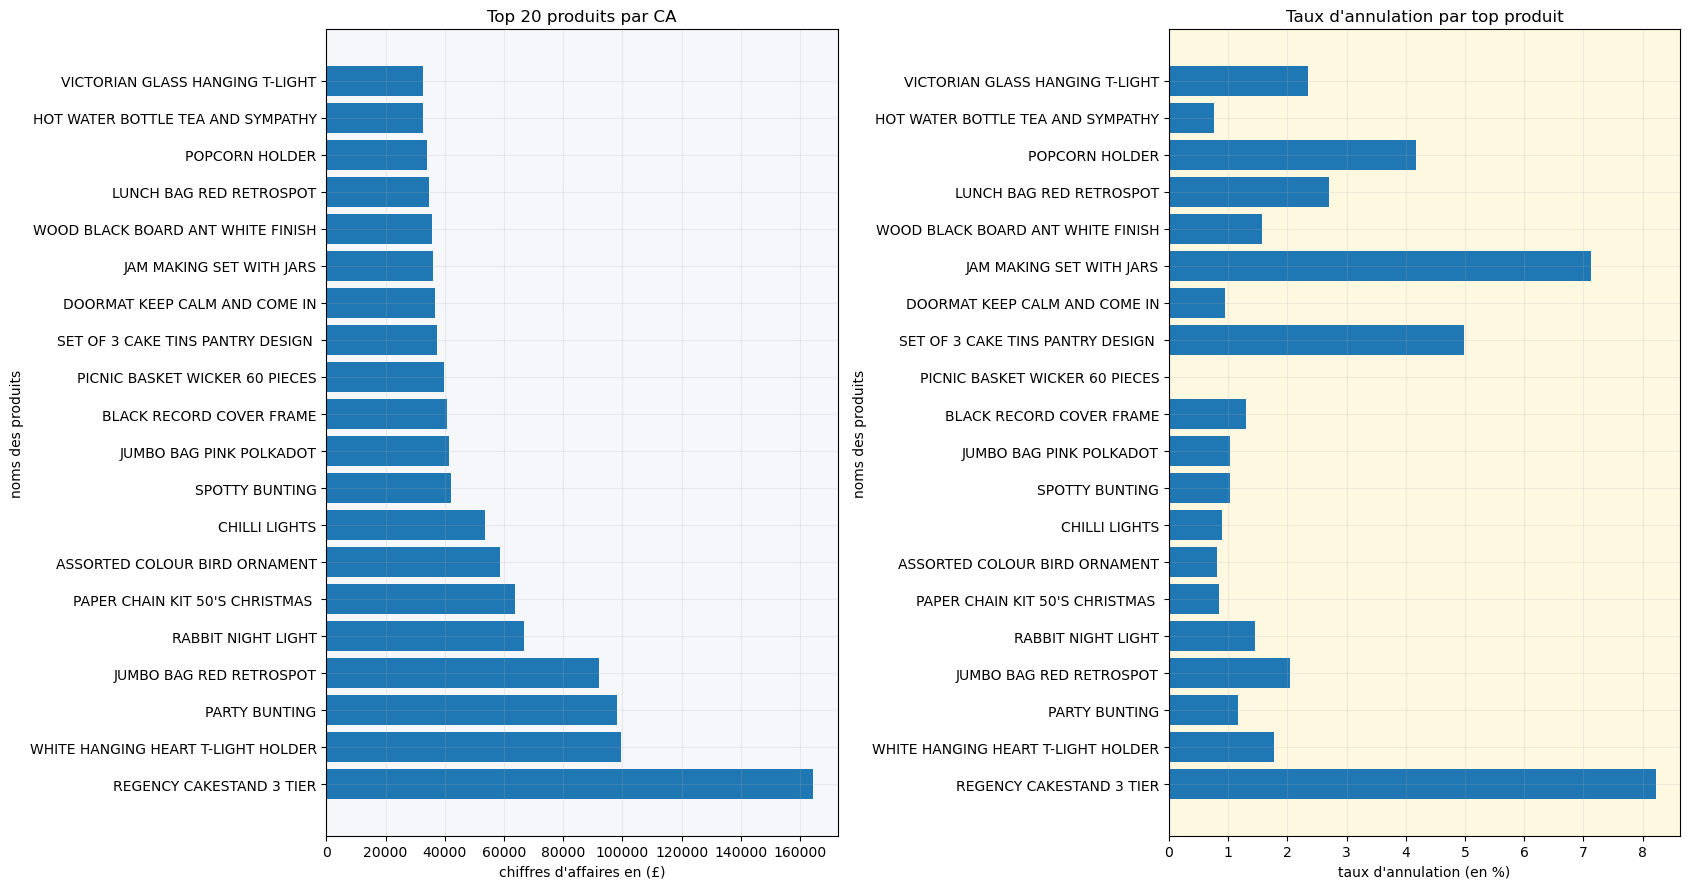

In [6]:
# base réutilisable pour la dimension Description

top20_ca = (
    recap
    .sort_values('CA (£)', ascending=False)
    .head(20)
)

# 1. Créer la Figure
fig = plt.figure(figsize=(17,9))

# 2. Créer la grille
gs = GridSpec(
    nrows=1,
    ncols=2,
    figure=fig
)

# 3. Créer les zones de dessin
ax1 = fig.add_subplot(gs[0,0])

ax2 = fig.add_subplot(gs[0,1])

# couleur de background
ax1.set_facecolor("#F5F7FA")
ax2.set_facecolor("#FFF8E1")

# grille légère par zone
ax1.grid(True, alpha=0.2)
ax2.grid(True, alpha=0.2)



# 4. Dessiner dans chaque zone
# Graphe 1 : Top 20 produits par CA
ax1.barh(
    y=top20_ca.index,
    width=top20_ca['CA (£)']
)
ax1.set_xlabel("chiffres d'affaires en (£)")
ax1.set_ylabel("noms des produits")
ax1.set_title("Top 20 produits par CA")

# Graphe 2 : taux d'annulation des memes produits
ax2.barh(
    y=top20_ca.index,
    width=top20_ca['Taux annulation(%)']
)
ax2.set_xlabel("taux d'annulation (en %)")
ax2.set_ylabel("noms des produits")
ax2.set_title("Taux d'annulation par top produit")


# 6. Mise en page finale
plt.tight_layout()
fig.savefig('../outputs/figures/classement_TOP_produit.png') 
plt.show()

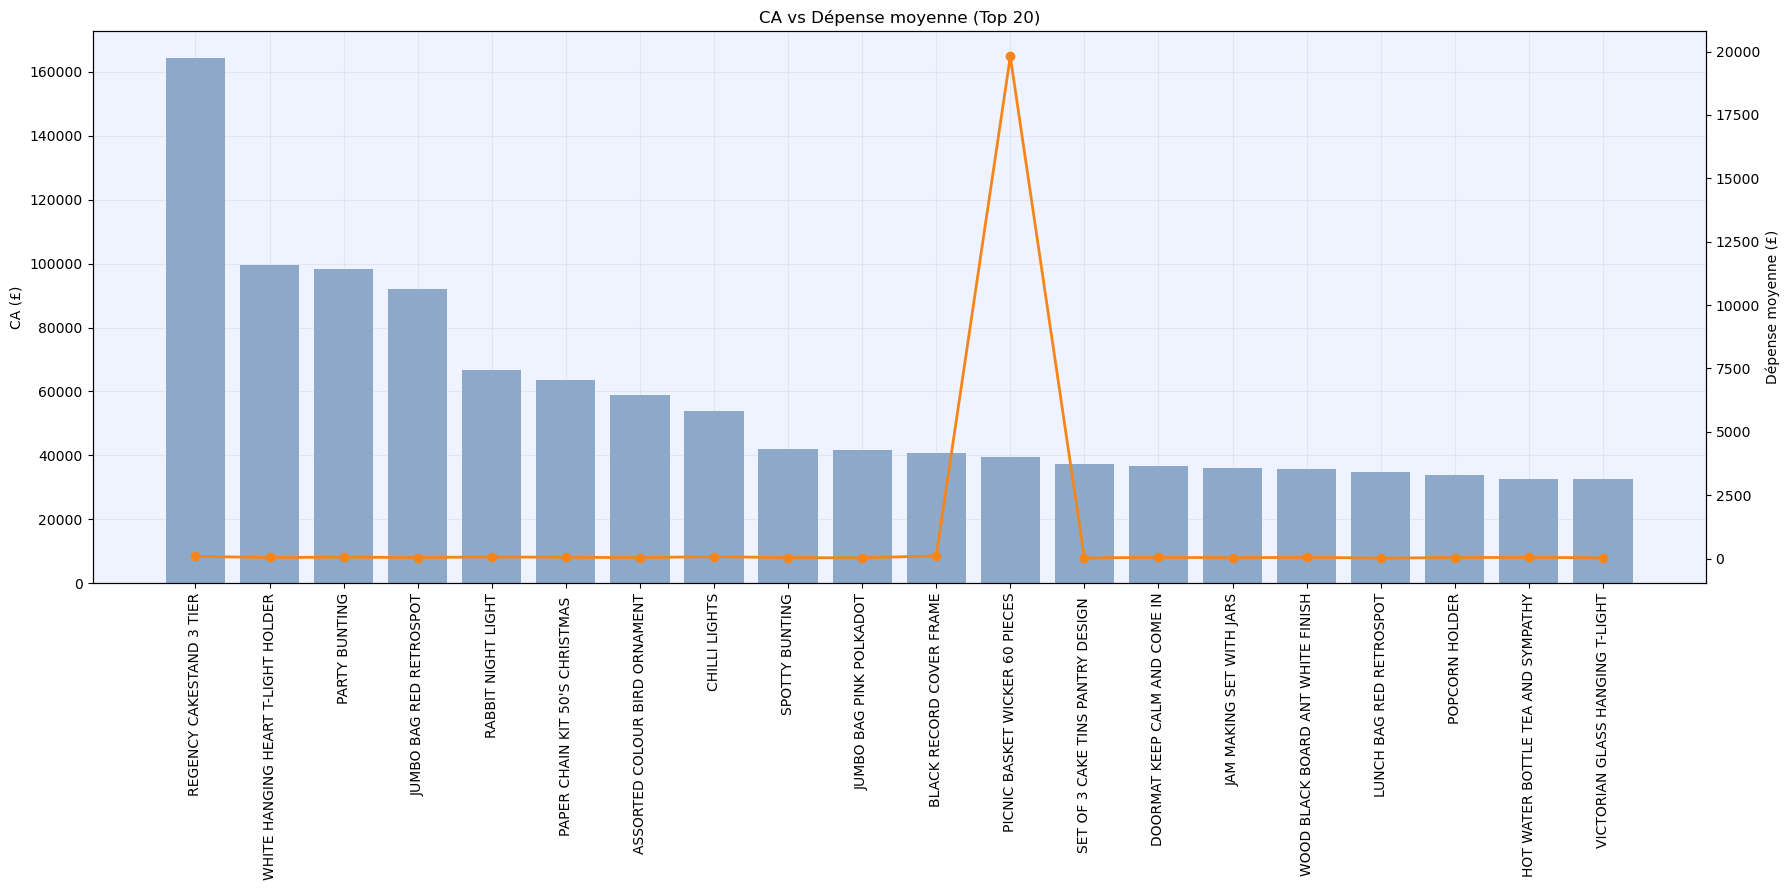

In [7]:
# 1. Créer la Figure

fig, ax3 = plt.subplots(figsize=(18,9))

ax3.set_facecolor("#EEF3FF")

ax3.grid(True, alpha=0.2)

bar_color = "#4C78A8"
line_color = "#F58518"

ax3.bar(
    top20_ca.index,
    top20_ca['CA (£)'],
    color = bar_color,
    alpha=0.6,
    zorder=1
)
ax3.set_title("CA vs Dépense moyenne (Top 20)")
ax3.set_ylabel("CA (£)")

ax3.tick_params(
    axis='x',
    rotation=90
)# Sinon les noms des produits vont se chevaucher.


# Créer le deuxième axe :
ax3b = ax3.twinx()

# Tracer la ligne :

ax3b.plot(
    top20_ca.index,
    top20_ca['Dépense moyenne(£)'],
    marker='o',
    color=line_color,
    linewidth=2,
    zorder=3
)
ax3b.grid(False)
ax3b.set_ylabel("Dépense moyenne (£)")

plt.tight_layout()
fig.savefig('../outputs/figures/contraste_CA_et_depense_moyenne.png')
plt.show()


----
## Lecture sur les produits
---

Le classement par CA désigne **REGENCY CAKESTAND 3 TIER** comme le produit le plus lucratif du catalogue. 
Pourtant, c'est aussi le produit qui affiche le taux d'annulation le plus élevé parmi les 20 premiers,
donc c'est un signal à ne pas ignorer.

À volume de commandes  bien moindre, **PICNIC BASKET WICKER 60 PIECES** se distingue comme un outsider structurel :
 - zéro annulation
 - dépense moyenne par transaction la plus haute
 - présence maintenue dans le top CA.
Un profil rare dans ce classement.

Pour le reste du top 20, le CA élevé s'explique presque exclusivement par le volume de transactions, 
La dépense moyenne par commande reste faible. Ce sont des produits qui se vendent beaucoup,
pas des produits pour lesquels le client dépense cher.

In [8]:
e_sales_pays = e_sales_produits.copy()
# UK inclus
# Calcul du taux d'annulation par pays
taux_pays = e_sales_pays.groupby('Country').agg(
    total   =('InvoiceNo', 'count'),    # total : nombre de lignes (toutes transactions, ventes + annulations)
    annulees=('InvoiceNo', lambda x: x.str.startswith('C').sum())  # annulees : parmi ces lignes, celles dont l'InvoiceNo commence par 'C'
)                                                                  # le préfixe 'C' est la marque officielle d'annulation dans ce dataset

taux_pays['taux_annulation'] = (taux_pays['annulees'] / taux_pays['total'] * 100).round(2)

# Tableau récapitulatif

tableau_pays = pd.DataFrame({
    'CA (£)'            : e_sales_pays.groupby('Country')['TotalPrice'].sum().round(2), 
    'Nb commandes'   : e_sales_pays.groupby('Country')['InvoiceNo'].nunique(),
    'Nb transactions': e_sales_pays.groupby('Country')['InvoiceNo'].count(),
    'Taux annulation(%)': taux_pays['taux_annulation'] 
})

# UK exclus
pays_exclus = ['United Kingdom']

# tableau sans le Royaume-Uni qui servira de base de calcul
e_sales_sans_uk = e_sales_pays[~e_sales_pays['Country'].isin(pays_exclus)]

# Calcul du taux d'annulation 
taux_sans_uk = e_sales_sans_uk.groupby('Country').agg(
    total   =('InvoiceNo', 'count'),    # total : nombre de lignes (toutes transactions, ventes + annulations)
    annulees=('InvoiceNo', lambda x: x.str.startswith('C').sum())  # annulees : parmi ces lignes, celles dont l'InvoiceNo commence par 'C'
)                                                                  # le préfixe 'C' est la marque officielle d'annulation dans ce dataset

taux_sans_uk['taux_annulation'] = (taux_sans_uk['annulees'] / taux_sans_uk['total'] * 100).round(2)

# Tableau récapitulatif

tableau_sans_uk = pd.DataFrame({
    'CA (£)'            : e_sales_sans_uk.groupby('Country')['TotalPrice'].sum().round(2), 
    'Nb commandes'   : e_sales_sans_uk.groupby('Country')['InvoiceNo'].nunique(),
    'Nb transactions': e_sales_sans_uk.groupby('Country')['InvoiceNo'].count(),
    'Taux annulation(%)': taux_sans_uk['taux_annulation'] 
})

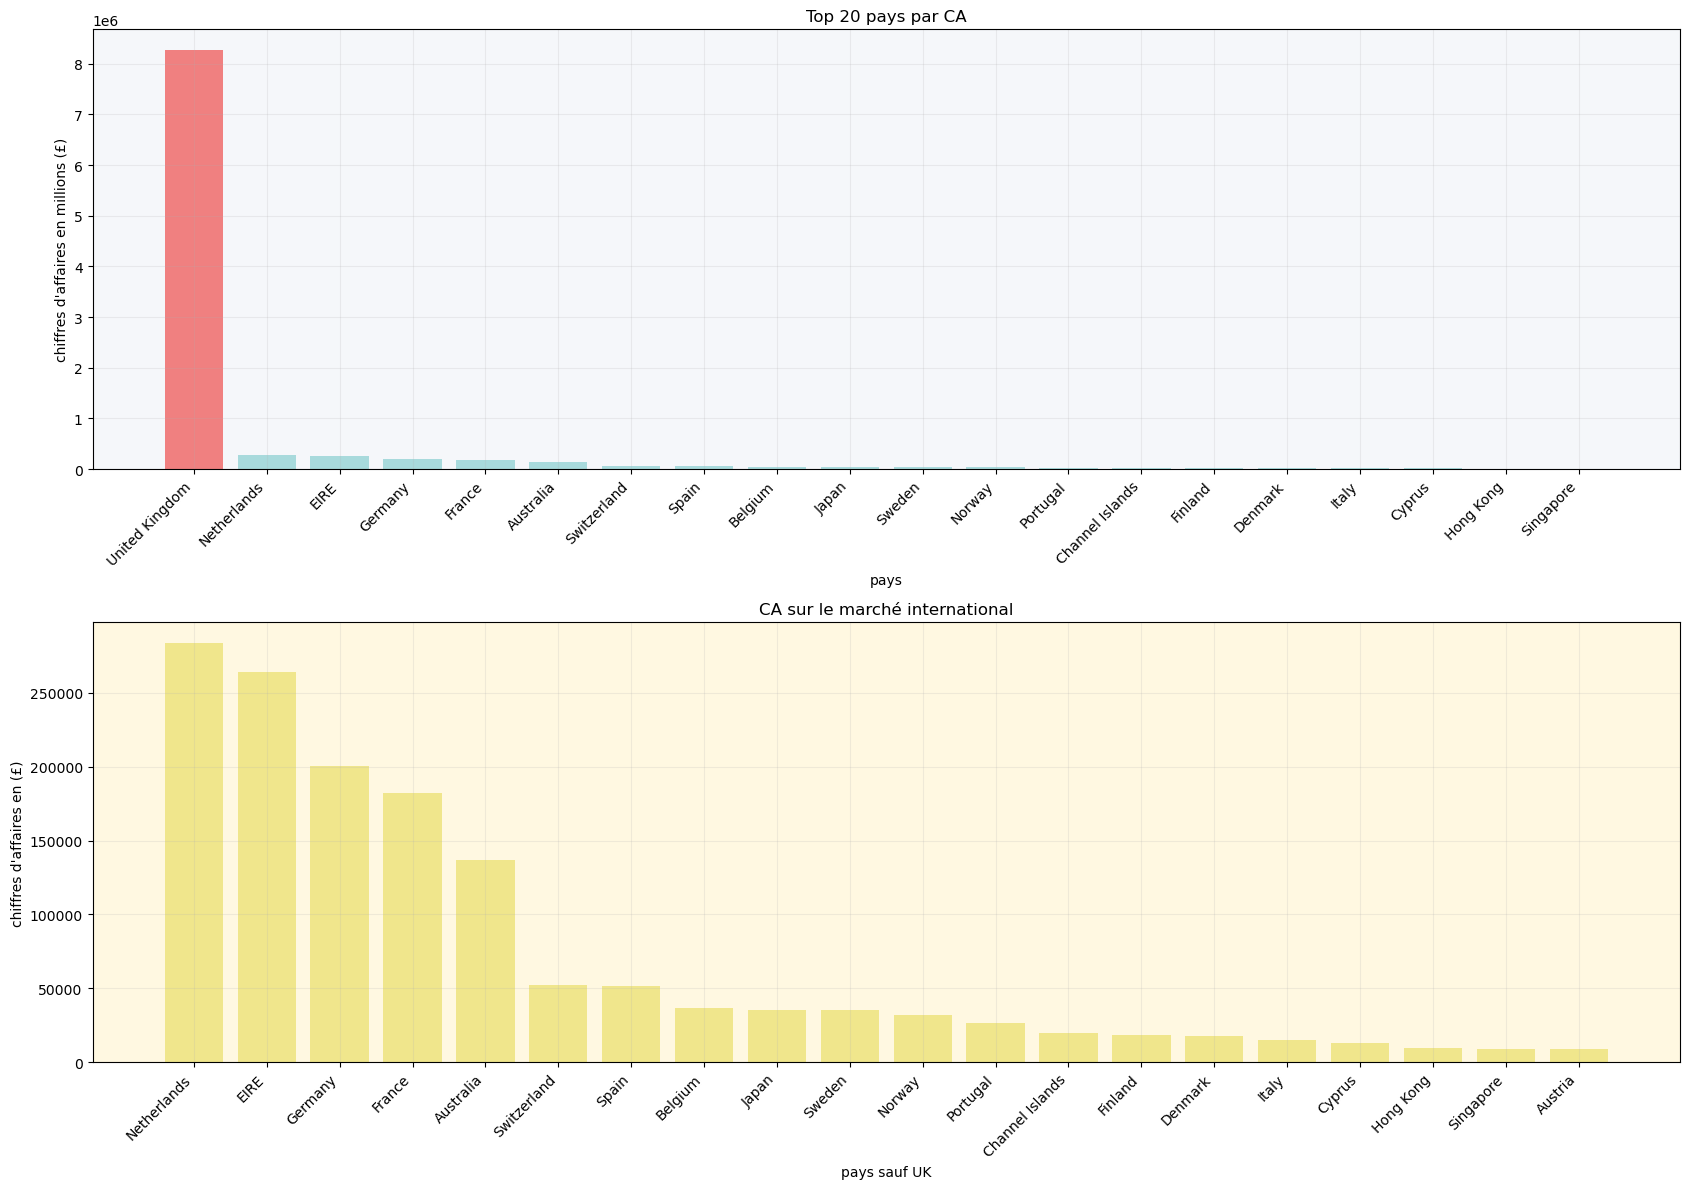

In [9]:
# base réutilisable
top20_pays = (
    tableau_pays
    .sort_values('CA (£)', ascending=False)
    .head(20)
)
top_20_sans_UK = (
    tableau_sans_uk
    .sort_values('CA (£)', ascending=False)
    .head(20)
)
# 1. Créer la Figure
fig = plt.figure(figsize=(17,12))

# 2. Créer la grille
gs = GridSpec(
    nrows=2,
    ncols=1,
    figure=fig
)

# 3. Créer les zones de dessin
ax1 = fig.add_subplot(gs[0,0])

ax2 = fig.add_subplot(gs[1,0])

# couleur de background
ax1.set_facecolor("#F5F7FA")
ax2.set_facecolor("#FFF8E1")

# grille légère par zone
ax1.grid(True, alpha=0.2)
ax2.grid(True, alpha=0.2)


# différenciateur de couleur
pays_max = top20_pays['CA (£)'].idxmax()
couleurs = ['#F08080' if pays == pays_max else '#A8DADC' for pays in top20_pays.index]

# 4. Dessiner dans chaque zone
# Graphe 1 : tous les pays par CA
ax1.bar(
    x = top20_pays.index,
    height = top20_pays['CA (£)'],
    color  = couleurs 
)
ax1.set_xlabel("pays")
ax1.set_ylabel("chiffres d'affaires en millions (£)")
ax1.set_title("Top 20 pays par CA")
plt.setp(ax1.get_xticklabels(), rotation=45, ha='right')


# Graphe 2 : uk exclus
ax2.bar(
    x = top_20_sans_UK.index,
    height = top_20_sans_UK['CA (£)'],
    color = '#F0E68C'
)
ax2.set_xlabel("pays sauf UK")
ax2.set_ylabel("chiffres d'affaires en (£)")
ax2.set_title("CA sur le marché international")
plt.setp(ax2.get_xticklabels(), rotation=45, ha='right')

# 6. Mise en page finale
plt.tight_layout()
fig.savefig('../outputs/figures/CA_par_pays.png')
plt.show()


---
## lecture sur les pays:
---
le **marché local britannique** concentre pratiquement toute la rentabilité de la boutique.

Le marché international, lui, n'est pas très lucratif, il reste marginal en valeur, mais aussi en volume.

un cas pour illustrer, ce sont **les USA**:
Il est absent pas dans le classement du top 20, mais se retrouve **30ème sur l'ensemble**
avec un **taux d'annulation de 38%**, signe déjà préoccupant, mais  combiné avec **un faible chiffre d'affaires**,
Ces informations suggèrent à la fois un marché peu développé et peu fiable.


In [10]:
e_sales_client = e_sales_produits.copy()

# Tableau récapitulatif
tableau_client = pd.DataFrame({
    'CA (£)'            : e_sales_client.groupby('CustomerID')['TotalPrice'].sum().round(2), 
    'Nb commandes'   : e_sales_client.groupby('CustomerID')['InvoiceNo'].nunique(),
})

# Isoler les clients inconnus
unknown = e_sales_client[e_sales_client['CustomerID'] == 'Unknown']

# Panorama complet
panorama = unknown.groupby('Country').agg(
    ca_total         = ('TotalPrice', 'sum')
).round(2)

# Proportions ajoutées après l'agg()
panorama['part_ca_%']           = (panorama['ca_total']/ tableau_pays['CA (£)']   * 100).round(2)

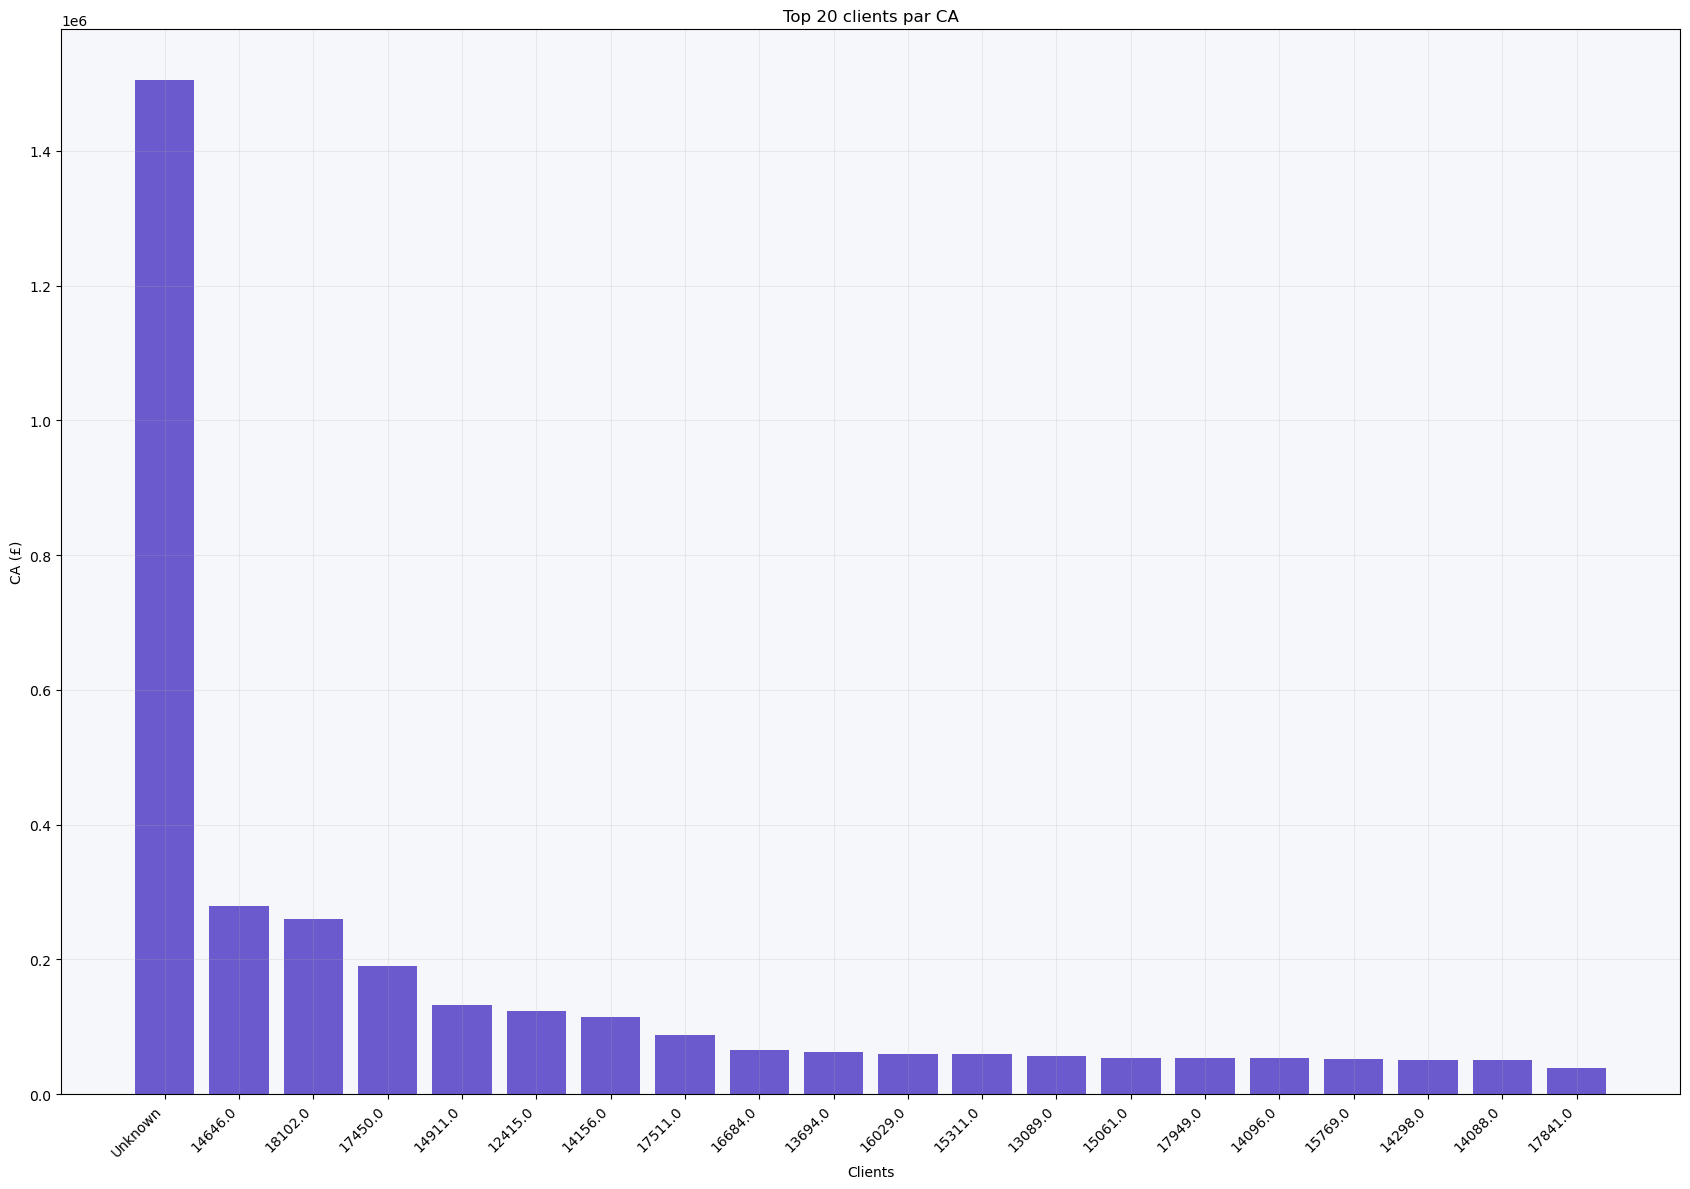

In [11]:
# base réutilisable pour la dimension Client

topclient_ca = (
    tableau_client
    .sort_values('CA (£)', ascending=False)
    .head(20)
)

fig = plt.figure(figsize=(17, 12))
ax = fig.add_subplot(1, 1, 1) 

#  Graphe  : Top 20 clients par CA 
ax.set_facecolor("#F5F7FA")
ax.grid(True, alpha=0.2)

ax.bar(
    x      = topclient_ca.index,
    height = topclient_ca['CA (£)'],  
    color  = '#6A5ACD'
)
ax.set_xlabel("Clients")
ax.set_ylabel("CA (£)")
ax.set_title("Top 20 clients par CA")
plt.setp(ax.get_xticklabels(), rotation=45, ha='right')

plt.tight_layout()
fig.savefig('../outputs/figures/classement_TOP_client.png')
plt.show()

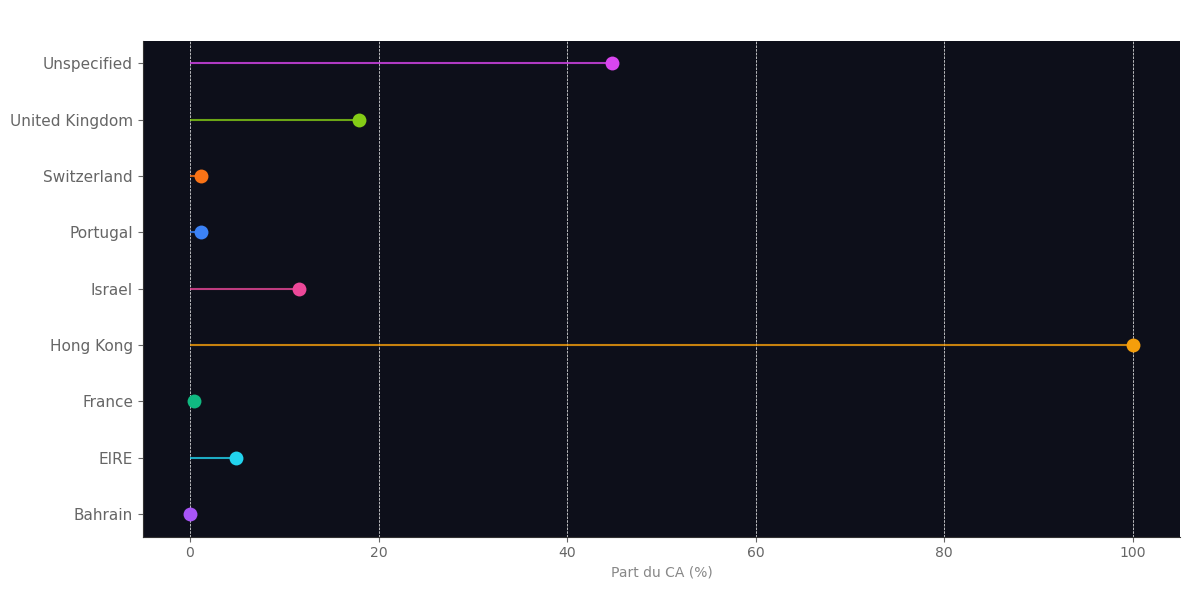

In [12]:
# on élimine les pays qui n'ont pas de client unknown
panorama_clean = panorama.dropna(subset=['part_ca_%'])

# Données triées par part décroissante
pays   = panorama_clean.index.tolist()
parts  = panorama_clean['part_ca_%'].values   # remplace par tes vraies valeurs

# Couleurs néon — une par pays
couleurs = ['#A855F7','#22D3EE','#10B981','#F59E0B',
            '#EC4899','#3B82F6','#F97316','#84CC16','#D946EF']

fig, axunknown = plt.subplots(figsize=(12, 6))

# Background sombre
axunknown.set_facecolor('#0D0F1A')

# Lollipops
for i, (p, v, c) in enumerate(zip(pays, parts, couleurs)):
    axunknown.hlines(y=i, xmin=0, xmax=v,
                     color=c, linewidth=1.5, alpha=0.8)
    axunknown.plot(v, i, 'o',
                   color=c, markersize=10,
                   markeredgewidth=0,
                   zorder=5)

# Axes et labels
axunknown.set_yticks(range(len(pays)))
axunknown.set_yticklabels(pays, color='#CCCCCC', fontsize=11)
axunknown.set_xlabel("Part du CA (%)", color='#888888')
axunknown.set_title("Part du CA des clients Unknown par pays",
                     color='white', fontsize=13, pad=12)

# Style sombre
axunknown.tick_params(colors='#666666')
axunknown.spines['bottom'].set_color('#333333')
axunknown.spines['left'].set_color('#333333')
axunknown.spines['top'].set_visible(False)
axunknown.spines['right'].set_visible(False)
axunknown.grid(axis='x', color='#ffffff0d', linewidth=0.5, linestyle='--')

plt.tight_layout()
fig.savefig('../outputs/figures/part_CA_unknown_par_pays.png')
plt.show()


---
## lecture sur les clients
---

Le **segment Unknown** domine le classement des Top 20 clients par CA , de ce fait, il devance tous les clients identifiés individuellement.
Une grande activité de valeur générée par des acheteurs sans profils connus.

Ces clients anonymes sont présents dans 9 pays. Certains marchés leur sont presque entièrement acquis : 
  - Hong Kong ne compte aucun client identifié
  - Le ou les territoires "Unspecified" leur doivent 44% de leur CA.
Des marchés où la boutique vend, mais ne connaît personne.

In [13]:
e_sales_dates = e_sales_produits.copy()

e_sales_dates = e_sales_dates[
    ~(
        (e_sales_dates['year'].isin([2010,2011])) &
        (e_sales_dates['month'] == 12)
    )
]

# Panorama complet
periode = e_sales_dates.groupby('month').agg(
    ca_total         = ('TotalPrice', 'sum')
).round(2)

jour_ventes = e_sales_dates.groupby('day')['InvoiceNo'].nunique().reset_index()
jour_ventes.columns = ['jour_semaine', 'nb_ventes']


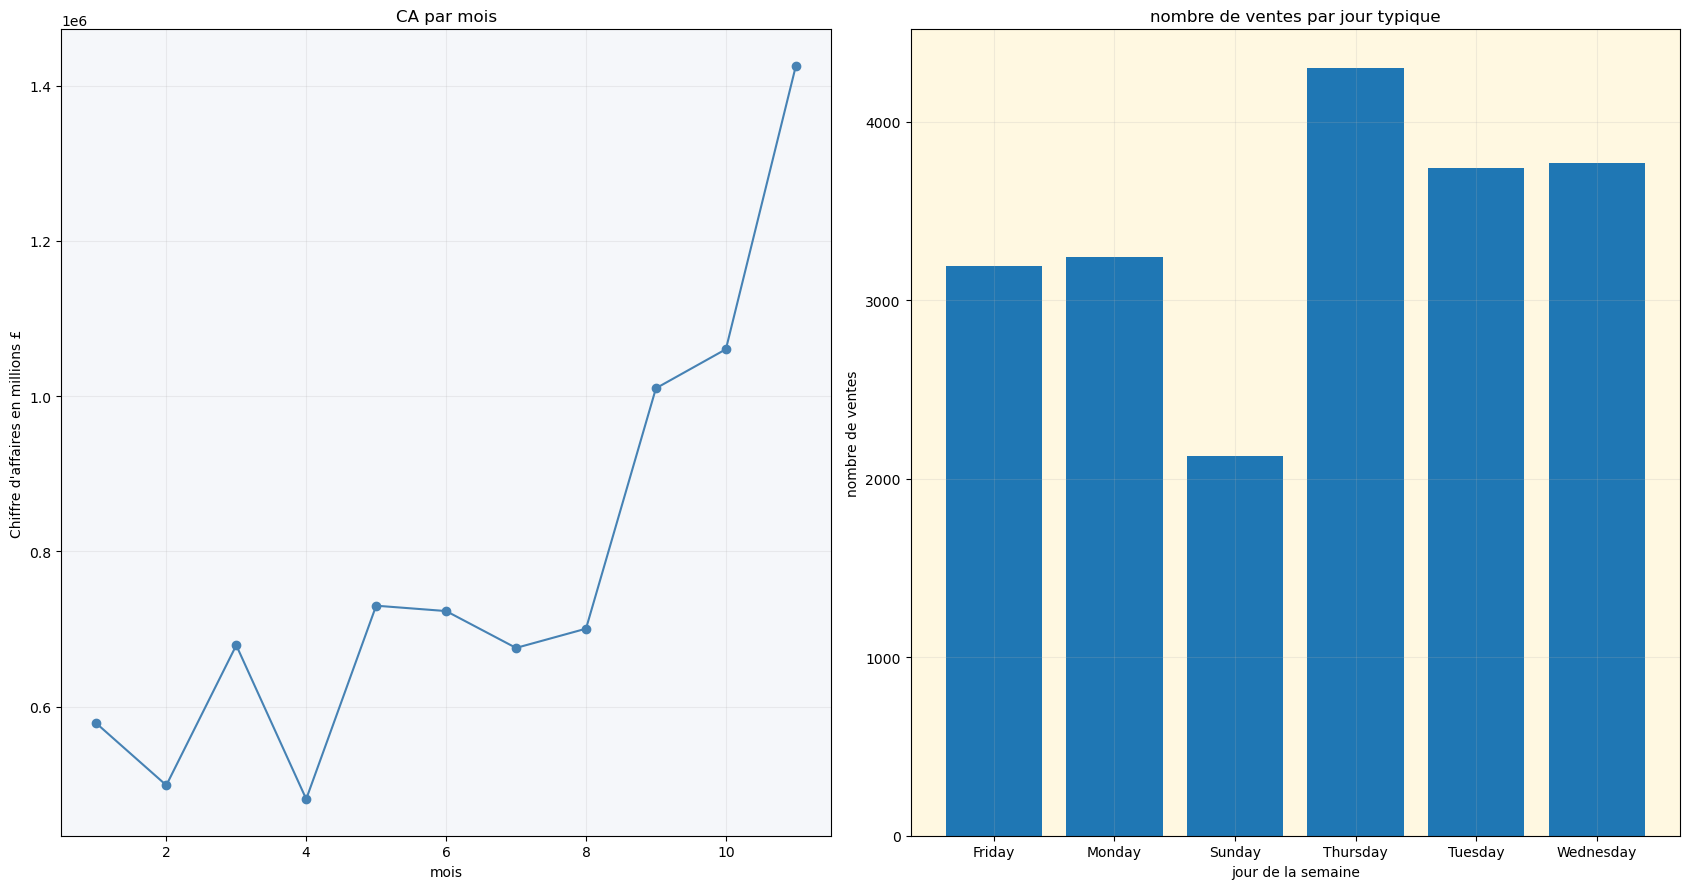

In [14]:

# 1. Créer la Figure
fig = plt.figure(figsize=(17,9))

# 2. Créer la grille
gs = GridSpec(
    nrows=1,
    ncols=2,
    figure=fig
)

# 3. Créer les zones de dessin
ax1 = fig.add_subplot(gs[0,0])

ax2 = fig.add_subplot(gs[0,1])

# couleur de background
ax1.set_facecolor("#F5F7FA")
ax2.set_facecolor("#FFF8E1")

# grille légère par zone
ax1.grid(True, alpha=0.2)
ax2.grid(True, alpha=0.2)



# 4. Dessiner dans chaque zone
# Graphe 1 : CA par mois
ax1.plot(
    periode.index,
    periode['ca_total'],
    marker='o', 
    color='steelblue'
)
ax1.set_xlabel("mois")
ax1.set_ylabel("Chiffre d'affaires en millions £")
ax1.set_title("CA par mois")

# Graphe 2 : taux d'annulation des mêmes produits
ax2.bar(
    x = jour_ventes['jour_semaine'],
    height = jour_ventes['nb_ventes']
)
ax2.set_xlabel("jour de la semaine")
ax2.set_ylabel("nombre de ventes")
ax2.set_title("nombre de ventes par jour typique")

# 6. Mise en page finale
plt.tight_layout()
fig.savefig('../outputs/figures/saisonnalité_et_jours_de_ventes.png')
plt.show()


---
## lecture sur les dimensions temporelles
---

La saisonnalité est marquée : **les revenus progressent nettement en fin d'année**, portés par les achats de la période festive. 
À l'opposé, **le début d'année marque un creux**, avec avril comme point bas de la période analysée.

En semaine, jeudi concentre le plus grand nombre de commandes. Le dimanche enregistre le volume le plus faible.



---
# Synthèses des visualisations
---
- Les visualisations de cette quatrième phase reposent exclusivement sur Matplotlib. 
Seaborn, bien que prévue initialement dans le projet,  n'a pas été nécessaire : aucune des problématiques ne justifiait un histogramme, une heatmap ou un boxplot.

- Le bar chart domine l'ensemble des dimensions. Ce n'est pas un manque d'ambition visuelle, mais c'est le type de graphique le plus adapté à des comparaisons entre catégories, qui constituent l'essentiel des questions posées dans ce projet.

- Les constats analytiques se limitent aux insights identifiés en Phase 3 et confirmés visuellement ici. L'interprétation et les recommandations sont réservées à la Phase 6.

- La Phase 5 introduira une augmentation par IA, dont le périmètre est strictement délimité : la génération automatique d'un résumé des KPI et insights, sans ajout d'interprétation.